# Research Notebook
## Caleb Miller
## Date: March 16 - March 22, 2026

# 1: Experience
## Research activities this week

Wrote Python code to model gas density profiles for several galaxy systems using data from the Humphrey et al. (2006) dataset.

Implemented and tested an MCMC fitting pipeline using the `emcee` library to constrain model parameters, including halo mass $(M_{200})$, concentration $(c)$, gas density normalization $(\rho_0)$, transition radius $(r_m)$, and stellar mass-to-light ratio $(\Upsilon)$.

Analyzed the resulting parameter distributions using walker trace plots and corner plots to assess convergence and identify correlations between parameters.

Used the MCMC results to generate best-fit gas density profiles and compared them to the observed data for multiple systems.

Attended research group meetings to discuss fitting results and strategies for improving model constraints.

## Motivation

The aim of this project is to study the hot X-ray–emitting gas in galaxy groups and use it to infer the underlying dark matter distribution under the assumption of hydrostatic equilibrium. In previous weeks we developed the temperature and gas modeling modules, which compute the temperature profile and solve the hydrostatic equilibrium equation for the gas density. This week I focused on applying MCMC methods to the gas density data from the Humphrey et al. (2006) dataset to explore how well the model parameters can be constrained. The goal was to assess the reliability of the fits and identify any degeneracies between parameters in the mass model.

# 2: What? (What happened?)
## Describe what happened during your activities for the week.

## Gas Density Modeling with MCMC

In this work, I used the gas and temperature models developed in previous weeks to compute theoretical gas density profiles for several galaxy systems. The goal was to compare these model predictions to observed gas density data from Humphrey et al. (2006) and use MCMC methods to constrain the parameters of the mass model.

I wrote Python code to load gas density data (radius, density, and uncertainties) for each galaxy system from an Excel file and use these as inputs to the fitting procedure. For a given set of model parameters, the code computes the corresponding gas density profile and compares it directly to the observed data.

To quantify how well the model fits the data, I constructed a likelihood function based on a chi-squared statistic,

$$
\chi^2 = \sum_i \frac{\left(\rho_i - \rho_{\mathrm{model}}(r_i)\right)^2}{\sigma_i^2},
$$

where $\rho_i$ and $\sigma_i$ are the observed densities and uncertainties. 

I then implemented a Markov Chain Monte Carlo (MCMC) procedure using the `emcee` library to explore the parameter space. The parameters varied in the model were $\log_{10}(M_{200})$, $c$, $\log_{10}(\rho_0)$, $r_m$, and $\Upsilon$. For each proposed set of parameters, the code computes the gas density profile and evaluates the likelihood. If the model produces nonphysical or invalid values, the likelihood is set to negative infinity so that the parameter set is rejected.

I initialized multiple walkers around an initial guess and ran the MCMC chains for a fixed number of steps. The resulting chains were analyzed using walker trace plots to assess convergence and determine whether the parameters stabilized over time. I also generated corner plots to visualize the posterior distributions and identify correlations between parameters.

Using the MCMC results, I extracted a representative best-fit parameter set corresponding to the maximum posterior probability. This parameter set was then used to compute the gas density profile, which was plotted together with the observational data. These plots were used to evaluate how well the model reproduces the observed gas density profiles.

The MCMC results and density profile fits were shared with the research group during our weekly meeting to evaluate the quality of the fits and to discuss the presence of degeneracies in the mass model.

---

# Code Used for Model Fitting

The Python code written this week loads the X-ray gas density data for several galaxy systems, computes theoretical gas density profiles using the hydrostatic equilibrium model, and fits the model to the data using Markov Chain Monte Carlo (MCMC) methods. The code uses the `emcee` library to sample the parameter space and determine the posterior distributions of the model parameters.

The code reads in the observed radii, gas densities, and measurement uncertainties from an Excel file and uses these as inputs to the fitting procedure. For each set of parameters, the code evaluates the gas density profile, converts it to the appropriate units, and compares it to the observational data using a chi-squared likelihood function.

After running the MCMC, the code extracts the best-fit parameters (maximum posterior sample), computes the corresponding gas density profile, and produces plots showing the observed density data with error bars alongside the best-fit model curve. The code also generates walker trace plots and corner plots to analyze convergence and parameter correlations.

The code below shows the implementation for fitting the gas density profile of a single system using MCMC. The same procedure is applied to the other galaxy systems, with only the input data and system name changing.

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import emcee
import corner
import warnings
import gas

warnings.filterwarnings("ignore")

# -----------------------------
# Configuration
# -----------------------------
SYSTEM = "N720"
FILE   = "Humphrey density data.xlsx"
SHEET  = "NGC720"

# -----------------------------
# Unit conversion
# -----------------------------
MSUN_G = 1.989e33
KPC_CM = 3.08568e21
MSUN_KPC3_TO_1E25_G_CM3 = (MSUN_G / KPC_CM**3) / 1e-25

# -----------------------------
# Load observed data
# -----------------------------
data = pd.read_excel(FILE, sheet_name=SHEET)

R_obs     = data["R (kpc)"].to_numpy(float)
rho_obs   = data["Density (10^-25 g/cm^3)"].to_numpy(float)
sigma_obs = data["Error Density (10^-25 g/cm^3)"].to_numpy(float)

# -----------------------------
# Initiate model
# -----------------------------
g = gas.gas(SYSTEM)

R0_FIXED   = 1.0
RMAX_FIXED = 5000.0

# -----------------------------
# Model function
# -----------------------------
def model_density(theta):
    log_M200, c, log_rho0, rm, Upsilon = theta

    M200 = 10.0**log_M200
    rho0 = 10.0**log_rho0

    try:
        sol = g.solve_rho_gas(
            rm=rm,
            M200=M200,
            c=c,
            r0=R0_FIXED,
            rmax=RMAX_FIXED,
            rho0=rho0,
            Upsilon=Upsilon
        )

        if sol.status != 0:
            return None

        rho_model = g.rho_gas(R_obs, sol)

        if np.any(~np.isfinite(rho_model)) or np.any(rho_model <= 0):
            return None

        return rho_model * MSUN_KPC3_TO_1E25_G_CM3

    except Exception:
        return None

# -----------------------------
# Likelihood
# -----------------------------
def log_likelihood(theta):
    rho_model = model_density(theta)
    if rho_model is None:
        return -np.inf
    return -0.5 * np.sum(((rho_obs - rho_model) / sigma_obs)**2)

# -----------------------------
# Prior
# -----------------------------
def log_prior(theta):
    log_M200, c, log_rho0, rm, Upsilon = theta

    if not (10.0 < log_M200 < 16.0): return -np.inf
    if not (1.0 < c < 30.0): return -np.inf
    if not (1.0 < log_rho0 < 10.0): return -np.inf
    if not (1.0 < rm < 200.0): return -np.inf
    if not (0.1 < Upsilon < 15.0): return -np.inf

    return 0.0

def log_probability(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

# -----------------------------
# Run MCMC
# -----------------------------
ndim = 5
nwalkers = 16
nsteps = 500

initial_guess = np.array([13.0, 10.0, 6.0, 10.0, 0.8])
pos = initial_guess + 0.1 * np.random.randn(nwalkers, ndim)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_probability)
sampler.run_mcmc(pos, nsteps, progress=True)

# -----------------------------
# Best-fit result
# -----------------------------
flat_samples = sampler.get_chain(discard=50, thin=10, flat=True)
flat_log_prob = sampler.get_log_prob(discard=50, thin=10, flat=True)

best_index = np.argmax(flat_log_prob)
best_fit = flat_samples[best_index]

rho_best = model_density(best_fit)

# -----------------------------
# Plot result
# -----------------------------
plt.figure(figsize=(7, 5))
plt.errorbar(R_obs, rho_obs, yerr=sigma_obs, fmt="o", label="Data")
plt.plot(R_obs, rho_best, label="Best-fit model")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("R (kpc)")
plt.ylabel(r"Density ($10^{-25}$ g cm$^{-3}$)")
plt.title(f"{SYSTEM}: Gas density fit")
plt.legend()
plt.show()

# 3: So what? (What does it mean?)
## Describe your results

| Density Fit | Corner Plot | Walker Traces |
|-------------|-------------|---------------|
| 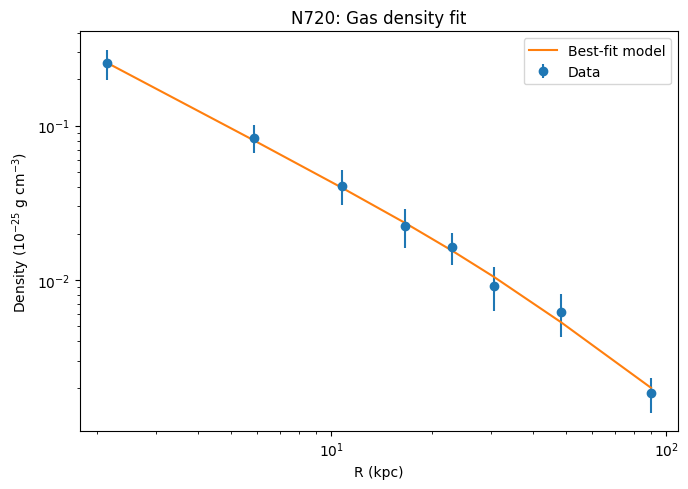 | 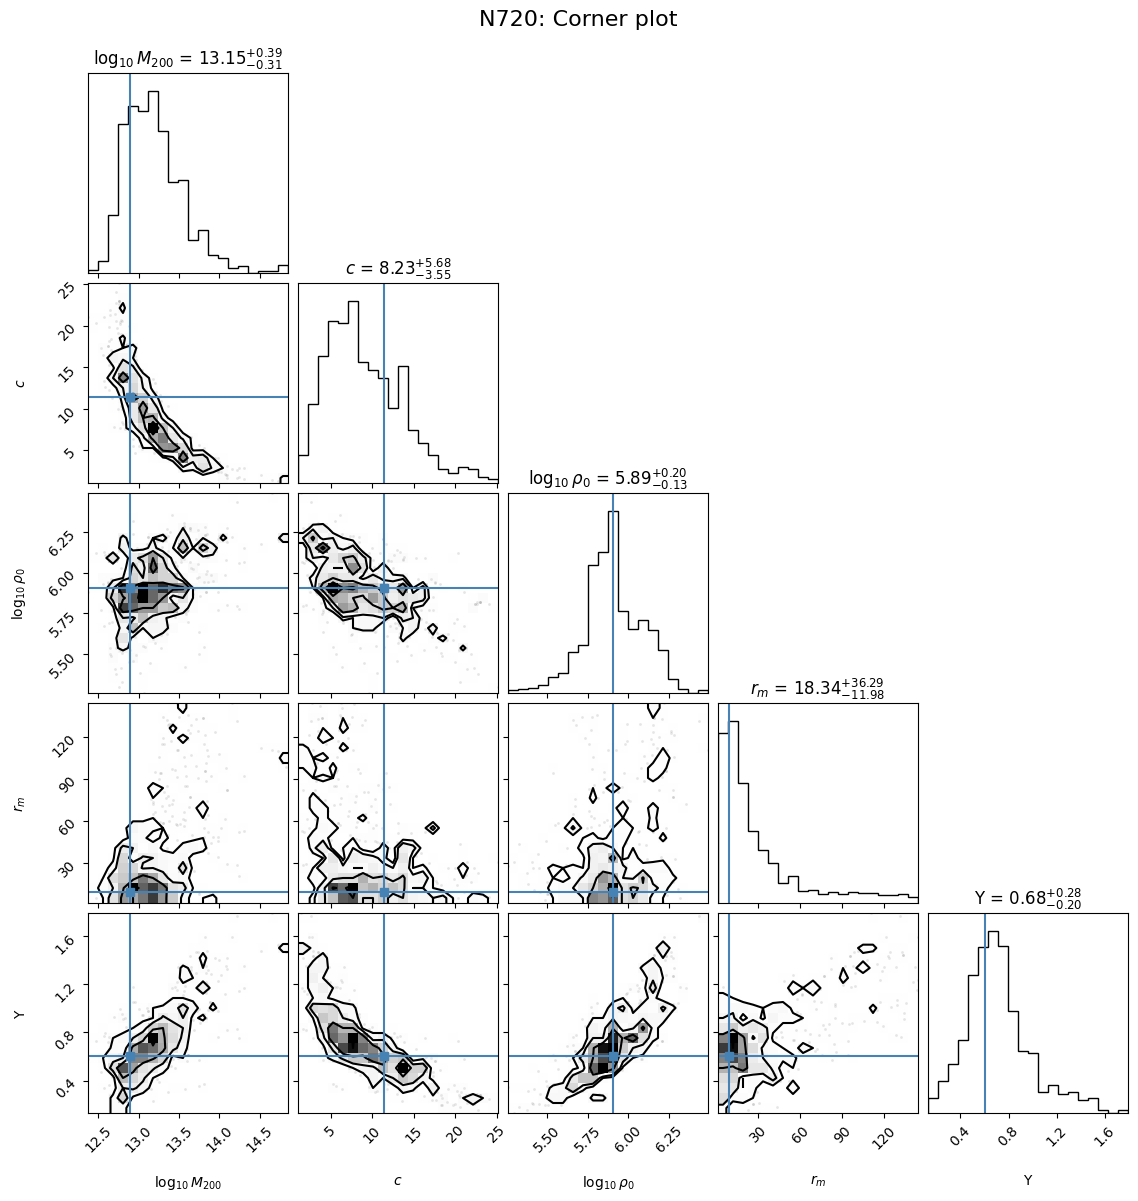 | 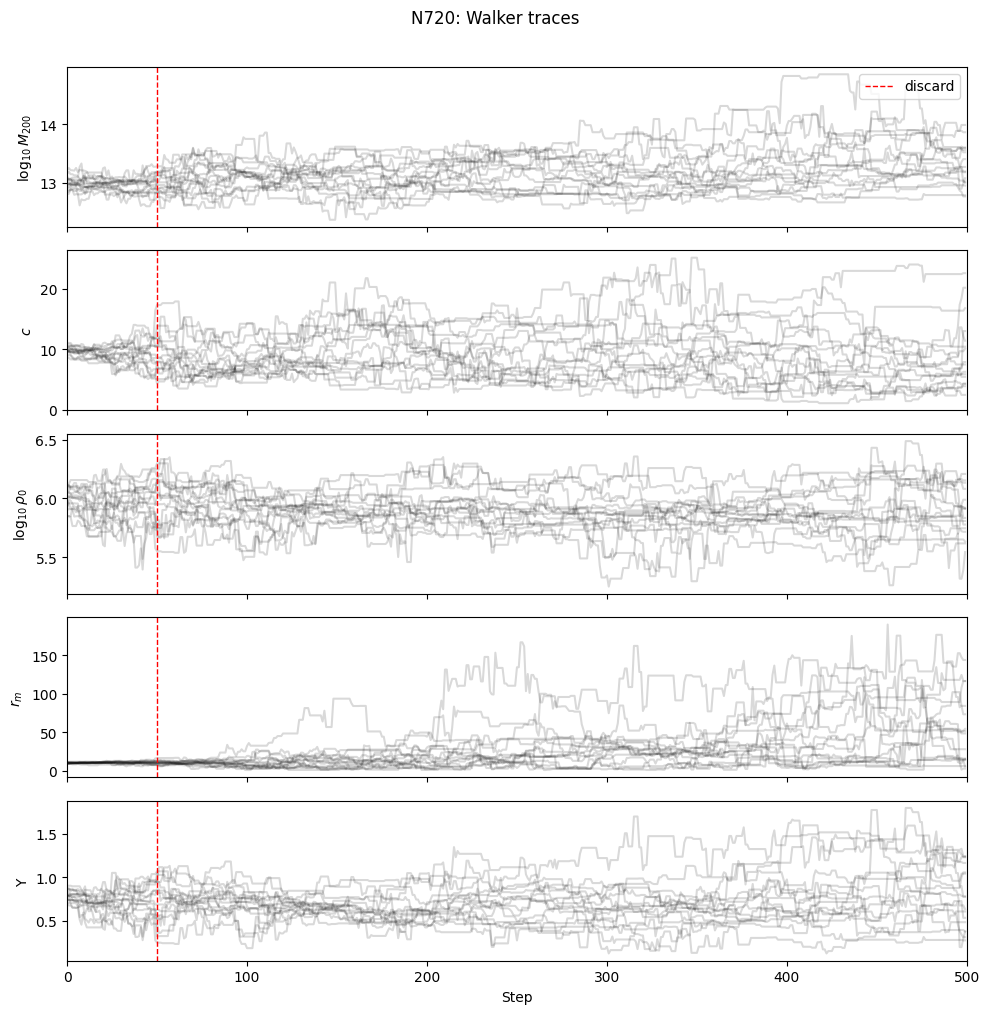 |

*Figure 1: Example results for the N720 galaxy system. The left plot is best-fit gas density profile compared to observed data. The middle plot is a corner plot showing posterior distributions and parameter correlations. The right plot is a walker trace plot used to assess convergence.*

This week’s main result was the successful implementation of an MCMC fitting procedure for modeling the gas density profiles of galaxy systems, demonstrated here using N720 as a representative example. The best-fit density profile closely follows the observed data across the full radial range, indicating that the hydrostatic equilibrium model is able to reproduce the overall behavior of the gas density.

The MCMC analysis also provided quantitative constraints on the model parameters. For N720, the halo mass was found to be $\log_{10}(M_{200}) \approx 13.15^{+0.39}_{-0.31}$, and the concentration parameter $c \approx 8.23^{+5.68}_{-3.55}$. The gas density normalization $\log_{10}(\rho_0) \approx 5.89^{+0.20}_{-0.13}$ is relatively well constrained, while the transition radius $r_m \approx 18.3^{+36.3}_{-12.0}\,\mathrm{kpc}$ and stellar mass-to-light ratio $\Upsilon \approx 0.68^{+0.28}_{-0.20}$ show much larger uncertainties.

The corner plot reveals strong correlations between several parameters, particularly between $M_{200}$ and $c$, indicating that these parameters are not independently constrained by the data. Instead, different combinations of halo mass and concentration can produce very similar density profiles. This degeneracy is also reflected in the broad and elongated contours in the posterior distributions.

The walker trace plot further shows that while some parameters, such as $\log_{10}(\rho_0)$, stabilize relatively quickly, others exhibit significant scatter and slow convergence. In particular, $r_m$ shows large fluctuations across the chains, suggesting that this parameter is weakly constrained by the data.

These results show that the MCMC fitting procedure can be successfully applied to the gas density data and is able to reproduce the observed density profiles for the Humphrey galaxy systems. The model captures the overall radial behavior of the gas density, indicating that the hydrostatic equilibrium framework provides a reasonable description of the data.

However, the MCMC analysis also reveals that not all model parameters are equally well constrained. In particular, the gas density normalization is generally well determined, while parameters such as the halo mass and concentration exhibit strong correlations, and quantities like the transition radius and stellar mass-to-light ratio remain poorly constrained. This suggests that multiple parameter combinations can produce similar density profiles.

This activity represents an important step in the overall project because it demonstrates both the strengths and limitations of the current modeling approach. While the MCMC framework provides a robust method for fitting the data and estimating uncertainties, it also highlights the need for additional constraints, such as fixing certain parameters, in order to obtain more precise results.

Overall, these results indicate that while the model is effective at reproducing the observed gas density profiles, the density data alone are not sufficient to uniquely determine all components of the mass model, highlighting the presence of degeneracies in the parameter space.

# <span style="color:magenta"> Notes </span>
<span style="color:magenta"> Nice work! I would like to hear a bit more about why some errors intervals are larger than its corresponding quantity. For MCMC, this usually indicates that the range of possible values is rather large. If you look at the plot above, that is exactly what is happening: For </span> $r_m$ <span style="color:magenta">, the shown range is almost quadruple of what the best fit indicates and all of these values still show some leftover possibility. This is an indication that the model does not constrain this parameter too strictly. For </span> $\rho_0$ <span style="color:magenta"> on the other hand though, the opposite is true: Your model seems to work well for constraining this.
</span>

# 4. Now what? (What's next?)
## Plan for the next week

This week I successfully implemented the MCMC fitting procedure to constrain the model parameters and used it to fit the gas density profiles of the Humphrey galaxy systems. Next week, I will use the posterior parameter sets from the MCMC chains to calculate the corresponding cross section values, $\sigma/m$, for each sample and use the resulting distribution to determine a $90\%$ upper limit on the cross section. This will allow me to translate the gas density fitting results into a physically meaningful constraint of the form $0 \leq \sigma/m \leq \sigma_{90}$. Additionally, I will work on preparing my presentation slides for the EXPLORE Workshop, focusing on the temperature models, MCMC fitting procedure, and cross section results.

# 5. Bibliography

[1] P. J. Humphrey et al., A Chandra View of Dark Matter in Early-Type Galaxies, Astrophys. J. 646, 899 (2006), arXiv:astro-ph/0601301.

| Category       | Points      |
| ------------- |:------------:|
| Formatting    |     2/2       |
| Experience    |     2/2       |
| What?         |     2/2       |
| So what?      |     4/4       |
| Now what?     |     4/4       |
| Bibliography  |     3/3       |
| Style         |     3/3       |
| Total         |    20/20      |

Nice work!